# Bonus B | Evaluation：你怎么知道模型变强了？

---

**目标：** 建立科学的模型评估体系

**核心问题：** 如何量化模型的能力？

---

## 本章内容

1. **Perplexity (PPL)**：语言模型的基础指标
2. **下游任务评测**：MMLU, GSM8K 等
3. **LLM-as-a-Judge**：用 GPT-4 评估
4. **实战**：构建评测脚本

---

## 📚 学习路线

| 前置章节 | 本章 | 下一章 |
|:---|:---|:---|
| ← [Ch7](../Ch7_Pretraining/Ch7_Pretraining.ipynb)-[Ch10](../Ch10_DPO/Ch10_DPO.ipynb) 全训练流水线 / [Bonus A: RLHF](../Bonus_A_RLHF/Bonus_A_RLHF.ipynb) | **Bonus B: Evaluation** | 应用实战 / 回顾总结 |

### 🎯 本章学习目标

1. 计算并理解 Perplexity（困惑度）作为语言模型质量指标的含义与局限
2. 使用 MMLU、GSM8K 等标准 Benchmark 评测模型能力
3. 构建 LLM-as-Judge 的评估 Prompt 并分析评审结果
4. 设计多维度的综合评测框架（雷达图可视化）

### 📋 前置知识

- 完整的训练流水线经验（来自 Ch7-Ch10）
- 了解 Loss 与模型质量的关系
- 对话模型的基本使用（来自 Ch8 SFT）

### ⏱ 预计用时

- 阅读理论：~20 分钟
- 运行代码：~15 分钟
- 完成练习：~10 分钟

---

## 前置知识：如何评价一个 LLM？

### 评估的重要性

训练了模型后，怎么知道它好不好？

**不能只看 Loss！** Loss 低不代表模型实际表现好。

### 评估的挑战

LLM 的输出是**开放式**的，没有标准答案：

```
问题: "写一首关于春天的诗"
回答A: "春风送暖入屠苏..."  好吗？
回答B: "Spring is coming..."  好吗？
```

怎么比较？怎么打分？

**评估拆解：** 先明确四件事
1. **评什么能力**：知识/推理/对话/安全等
2. **用什么数据**：公开基准 + 真实场景样本
3. **怎么打分**：准确率、pass@k、胜率、PPL 等
4. **如何控变量**：固定 prompt、温度、token budget

**注意：** 防止数据污染与提示差异导致结果不可比。

### 常见评估方法

| 方法 | 适用场景 | 特点 |
|:---|:---|:---|
| Perplexity | 语言模型质量 | 自动，但与实际表现有差距 |
| 基准测试 (Benchmark) | 特定能力 | 标准化，可比较 |
| 人工评估 | 真实场景 | 准确，但昂贵 |
| LLM-as-Judge | 大规模评估 | 用 GPT-4 打分 |

### 常用 Benchmark

- **MMLU**: 多学科知识
- **HumanEval**: 代码能力
- **GSM8K**: 数学推理
- **MT-Bench**: 对话能力

### 本章目标

- 理解各种评估方法的优缺点
- 学习如何使用常见 Benchmark
- 了解 LLM-as-Judge 的实现
- 设计自己的评估流程

**注：** 本章代码与图表使用模拟数据，仅用于演示评测流程。

## 0. 环境准备

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import json
import re

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

print("环境准备完成！")

环境准备完成！


---

## 1. Perplexity (PPL)：困惑度

### 什么是 PPL？

PPL 衡量模型对测试数据的"惊讶程度"：

$$PPL = \exp\left(-\frac{1}{N}\sum_{i=1}^N \log P(w_i|w_{<i})\right)$$

- **PPL 越低越好**：模型对数据越不"惊讶"
- 直觉：如果下一个词很难预测，PPL 就高

**局限性：** PPL 主要衡量语言建模能力，对指令遵循/推理不敏感；不同领域或 tokenizer 间不可直接横比。
**注：** 下方 PPL 数值与曲线为模拟示例，用于展示趋势。

### 评估方法深层理论

#### 1. Perplexity 的局限性

PPL 是语言模型最基础的自动指标，但它存在严重的局限性：

**PPL 衡量的是什么？** PPL 衡量模型对测试文本的"惊讶程度"——即模型分配给正确下一个 token 的概率有多高。但这只衡量了**语言建模能力**，不衡量其他关键能力：

| PPL 能衡量 | PPL 不能衡量 |
|-----------|-------------|
| 语法流畅度 | 指令遵循能力 |
| 词汇搭配自然度 | 事实准确性 |
| 上下文连贯性 | 推理正确性 |
| | 安全性与价值对齐 |
| | 回答的有帮助程度 |

**反直觉的例子：** 一个 PPL 很低的模型可能会：
- 流畅地编造虚假事实（幻觉）
- 完美地忽略用户指令（不对齐）
- 优雅地生成有害内容（不安全）

**PPL 不可跨模型比较的原因：**
- 不同 tokenizer 会影响 PPL 的计算（token 粒度不同，PPL 数值不可比）
- 不同训练数据的模型，PPL 在同一测试集上的含义不同

#### 2. Benchmark 饱和问题

随着模型能力的快速提升，许多经典 benchmark 出现了"天花板效应"：

```
MMLU 准确率演进：
  GPT-3 (2020):     ~43%
  GPT-3.5 (2022):   ~70%
  GPT-4 (2023):     ~86%
  GPT-4o (2024):    ~88%
  Claude 3.5 (2024): ~89%

当所有强模型都在 85-90% 时，这个 benchmark 还能区分模型好坏吗？
```

**饱和的后果：**
- 模型之间的差异可能落在误差范围内
- 无法区分"真的理解"和"恰好背过答案"（数据污染问题）
- 社区转向更难的 benchmark：GPQA、MATH-500、SWE-bench 等

**数据污染（Data Contamination）：** 如果模型的训练数据中包含了 benchmark 的测试题，那么高分就不代表真实能力。检测方法包括：
- 检查 n-gram 重叠
- 用 benchmark 的变体（rephrased）版本重新测试
- 比较训练集内外题目的准确率差异

#### 3. LLM-as-Judge 详解（Zheng et al., 2023）

**核心思想：** 用一个强大的 LLM（如 GPT-4）作为"裁判"，对其他模型的输出进行评分或排序。

**常见评估模式：**

```
模式 1: 单答案评分（Single Rating）
  "请对以下回答打 1-10 分"
  → 简单，但绝对分数不稳定

模式 2: 成对比较（Pairwise Comparison）
  "以下两个回答，哪个更好？"
  → 更可靠，人类也更擅长比较

模式 3: 参考答案评分（Reference-guided）
  "参考标准答案，评估模型回答的正确性"
  → 适合有明确答案的任务
```

**LLM-as-Judge 的系统性偏差：**

| 偏差类型 | 表现 | 缓解方法 |
|---------|------|---------|
| **位置偏差（Position Bias）** | 倾向于选择出现在前面的回答 | 随机交换 A/B 的位置，取两次评估的一致结果 |
| **冗长偏差（Verbosity Bias）** | 倾向于选择更长、更详细的回答 | 在评分 rubric 中明确"简洁性"维度 |
| **自我偏好（Self-preference）** | GPT-4 偏向自己的输出风格 | 使用多个不同的 Judge 模型，交叉验证 |
| **格式偏差** | 使用 Markdown 格式的回答更容易获得高分 | 统一输出格式后再评估 |

#### 4. 人工评估：金标准但代价高昂

人工评估仍然是评估 LLM 输出质量的"金标准"，但存在实际挑战：

**标注者间一致性（Inter-annotator Agreement）：**
用 **Cohen's Kappa** 衡量两个标注者的一致性：

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

其中：
- $p_o$ = 观测到的一致率（两人实际一致的比例）
- $p_e$ = 偶然一致率（随机情况下预期的一致比例）

**Kappa 值的解读：**
| $\kappa$ 范围 | 一致性水平 |
|:---:|:---:|
| < 0.20 | 很差 |
| 0.21 - 0.40 | 一般 |
| 0.41 - 0.60 | 中等 |
| 0.61 - 0.80 | 较好 |
| 0.81 - 1.00 | 几乎完美 |

**数值例子：** 两位标注者各评估 100 个回答（好/坏）：
- 两人一致的有 80 个（$p_o = 0.80$）
- 标注者 A 说"好"的比例 = 0.6，标注者 B 说"好"的比例 = 0.7
- $p_e = 0.6 \times 0.7 + 0.4 \times 0.3 = 0.54$
- $\kappa = (0.80 - 0.54) / (1 - 0.54) = 0.57$（中等一致性）

**实践建议：**
- 主观任务（如"有帮助性"）的 $\kappa$ 通常较低（0.3-0.5）
- 客观任务（如"事实正确性"）的 $\kappa$ 通常较高（0.6-0.8）
- 当 $\kappa < 0.4$ 时，应重新检查评估标准的清晰度

In [2]:
def calculate_perplexity(logits, targets):
    """
    计算困惑度
    
    参数:
        logits: [batch, seq_len, vocab_size] 模型输出
        targets: [batch, seq_len] 目标 token
    
    返回:
        PPL 值
    """
    # 计算交叉熵损失
    loss = F.cross_entropy(
        logits.view(-1, logits.size(-1)),
        targets.view(-1),
        reduction='mean'
    )
    
    # PPL = exp(loss)
    ppl = torch.exp(loss)
    return ppl.item()

# 模拟测试
vocab_size = 1000
batch_size = 2
seq_len = 100

# 好模型：预测较准确
good_logits = torch.randn(batch_size, seq_len, vocab_size)
targets = torch.randint(0, vocab_size, (batch_size, seq_len))
# 让正确 token 有较高概率
good_logits.scatter_(-1, targets.unsqueeze(-1), 5.0)

# 差模型：随机预测
bad_logits = torch.randn(batch_size, seq_len, vocab_size)

ppl_good = calculate_perplexity(good_logits, targets)
ppl_bad = calculate_perplexity(bad_logits, targets)

print(f"好模型 PPL: {ppl_good:.2f}")
print(f"差模型 PPL: {ppl_bad:.2f}")
print(f"\n注意: 随机预测的 PPL ≈ vocab_size = {vocab_size}")

好模型 PPL: 12.06
差模型 PPL: 1713.04

注意: 随机预测的 PPL ≈ vocab_size = 1000


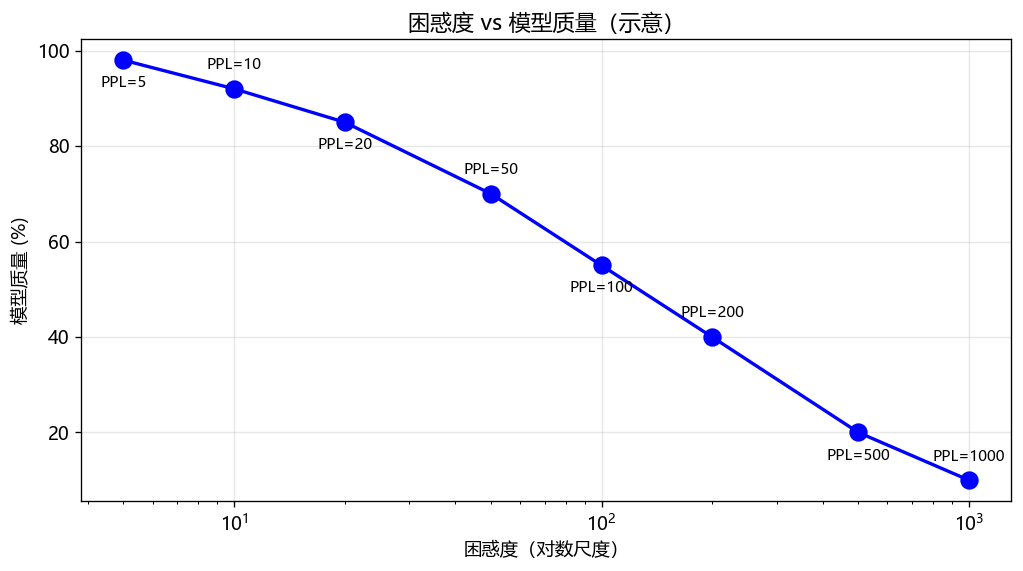

PPL 越低，模型越好
但 PPL 有局限性：只衡量语言建模能力，不反映其他能力


In [3]:
# 可视化 PPL 与模型质量的关系（示意）
ppls = [1000, 500, 200, 100, 50, 20, 10, 5]
quality = [10, 20, 40, 55, 70, 85, 92, 98]

plt.figure(figsize=(10, 5))
plt.plot(ppls, quality, 'bo-', linewidth=2, markersize=10)
plt.xscale('log')
plt.xlabel('困惑度（对数尺度）')
plt.ylabel('模型质量 (%)')
plt.title('困惑度 vs 模型质量（示意）')
plt.grid(True, alpha=0.3)

# 标注（修复重叠：交替上下偏移）
for idx, (p, q) in enumerate(zip(ppls, quality)):
    offset_y = 12 if idx % 2 == 0 else -16
    plt.annotate(f'PPL={p}', (p, q), textcoords="offset points",
                 xytext=(0, offset_y), ha='center', fontsize=9)

plt.show()

print("PPL 越低，模型越好")
print("但 PPL 有局限性：只衡量语言建模能力，不反映其他能力")

---

## 2. 下游任务评测

### 常见基准测试

| 基准 | 评测内容 | 示例 |
|:---|:---|:---|
| MMLU | 知识问答 | "法国的首都是哪里？" |
| GSM8K | 数学推理 | "如果小明有 5 个苹果..." |
| HumanEval | 代码生成 | "写一个函数来..." |
| TruthfulQA | 真实性 | 避免生成虚假信息 |

### 评测协议要点

- 明确 zero-shot / few-shot / CoT 设置
- 固定 prompt、温度、最大 token 等生成参数
- 使用官方数据拆分，避免训练污染

**注：** 下方 MMLU/GSM8K 代码与结果为模拟示例。


In [4]:
# 模拟 MMLU 评测
def evaluate_mmlu_sample(model_answer, correct_answer):
    """评估单个 MMLU 样本"""
    return model_answer.strip().upper() == correct_answer.strip().upper()

# 模拟 MMLU 数据
mmlu_samples = [
    {
        "question": "What is the capital of France?",
        "choices": ["A. London", "B. Paris", "C. Berlin", "D. Madrid"],
        "answer": "B"
    },
    {
        "question": "What is 2 + 2?",
        "choices": ["A. 3", "B. 4", "C. 5", "D. 6"],
        "answer": "B"
    },
    {
        "question": "What is the chemical symbol for water?",
        "choices": ["A. O2", "B. CO2", "C. H2O", "D. NaCl"],
        "answer": "C"
    },
]

# 模拟模型回答
model_answers = ["B", "B", "C"]  # 假设模型全对

# 评估
correct = sum(evaluate_mmlu_sample(ma, s["answer"]) 
              for ma, s in zip(model_answers, mmlu_samples))
accuracy = correct / len(mmlu_samples) * 100

print("MMLU 评测结果:")
print(f"  正确: {correct}/{len(mmlu_samples)}")
print(f"  准确率: {accuracy:.1f}%")

MMLU 评测结果:
  正确: 3/3
  准确率: 100.0%


In [5]:
# 模拟 GSM8K 评测
def evaluate_gsm8k(model_answer, correct_answer):
    """
    评估 GSM8K 样本
    提取数字答案进行比较
    """
    def extract_number(text):
        numbers = re.findall(r'-?\d+\.?\d*', text)
        return float(numbers[-1]) if numbers else None
    
    model_num = extract_number(model_answer)
    correct_num = extract_number(correct_answer)
    
    if model_num is None or correct_num is None:
        return False
    return abs(model_num - correct_num) < 0.01

# 模拟数据
gsm8k_samples = [
    {
        "question": "John has 5 apples. He gives 2 to Mary. How many does he have?",
        "answer": "3"
    },
    {
        "question": "A car travels 60 km in 1 hour. How far in 3 hours?",
        "answer": "180"
    },
]

# 模拟模型回答
model_answers = [
    "John has 5 - 2 = 3 apples left.",
    "60 * 3 = 180 km"
]

correct = sum(evaluate_gsm8k(ma, s["answer"]) 
              for ma, s in zip(model_answers, gsm8k_samples))
accuracy = correct / len(gsm8k_samples) * 100

print("GSM8K 评测结果:")
print(f"  正确: {correct}/{len(gsm8k_samples)}")
print(f"  准确率: {accuracy:.1f}%")

GSM8K 评测结果:
  正确: 2/2
  准确率: 100.0%


---

## 3. LLM 评审（LLM-as-a-Judge）

### 思想

用更强的模型（如 GPT-4）来评估其他模型的输出。

### 评估维度

- 有帮助性（Helpfulness）
- 无害性（Harmlessness）
- 诚实性（Honesty）

### 常见偏差与对策

- 位置/啰嗦偏差：随机打乱顺序，控制长度
- 评审一致性：多评审/多次投票，计算一致率
- 任务相关性：提供评分 rubric 或参考答案

**注：** 下方 LLM-as-a-Judge 结果统计为模拟示例。


In [6]:
def llm_judge_prompt(question, response_a, response_b):
    """
    构建 LLM-as-a-Judge 的 prompt
    """
    prompt = f"""Please evaluate the following two responses to the question.

Question: {question}

Response A: {response_a}

Response B: {response_b}

Please compare the responses based on:
1. Helpfulness: Does it answer the question well?
2. Accuracy: Is the information correct?
3. Clarity: Is it easy to understand?

Output your judgment as:
- "A" if Response A is better
- "B" if Response B is better
- "Tie" if they are equally good

Your judgment:"""
    return prompt

# 示例
question = "How do I learn Python?"
response_a = "Read the docs."
response_b = "Start with basics like variables and loops. Practice with small projects. Use online resources like Codecademy or freeCodeCamp."

prompt = llm_judge_prompt(question, response_a, response_b)
print("LLM Judge Prompt:")
print("=" * 60)
print(prompt)

print("\n" + "=" * 60)
print("(在实际中，将此 prompt 发送给 GPT-4)")

LLM Judge Prompt:
Please evaluate the following two responses to the question.

Question: How do I learn Python?

Response A: Read the docs.

Response B: Start with basics like variables and loops. Practice with small projects. Use online resources like Codecademy or freeCodeCamp.

Please compare the responses based on:
1. Helpfulness: Does it answer the question well?
2. Accuracy: Is the information correct?
3. Clarity: Is it easy to understand?

Output your judgment as:
- "A" if Response A is better
- "B" if Response B is better
- "Tie" if they are equally good

Your judgment:

(在实际中，将此 prompt 发送给 GPT-4)


LLM-as-a-Judge 结果统计:
  A: 20.0%
  B: 70.0%
  Tie: 10.0%


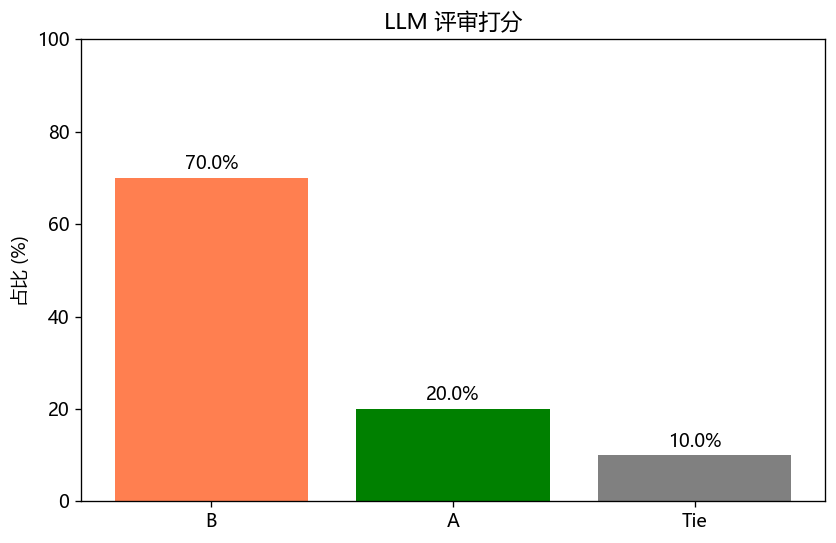

In [7]:
# 模拟评测结果统计
def analyze_judgments(judgments):
    """分析评测结果"""
    counts = defaultdict(int)
    for j in judgments:
        counts[j] += 1
    
    total = len(judgments)
    return {k: v/total*100 for k, v in counts.items()}

# 模拟多次评测结果
judgments = ["B", "B", "A", "B", "Tie", "B", "B", "A", "B", "B"]
results = analyze_judgments(judgments)

print("LLM-as-a-Judge 结果统计:")
for option, percentage in sorted(results.items()):
    print(f"  {option}: {percentage:.1f}%")

# 可视化
plt.figure(figsize=(8, 5))
bars = plt.bar(results.keys(), results.values(), color=['coral', 'green', 'gray'])
plt.ylabel('占比 (%)')
plt.title('LLM 评审打分')
plt.ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=11)

plt.show()

---

## 4. 评估集规模：为什么至少需要 100 题

10 题评估集只能做 smoke test：它能发现代码有没有跑通，但不足以判断模型或 Agent 是否真的变强。只要错 1 题，准确率就会跳动 10 个百分点，单个偶然样例会严重影响结论。

更稳妥的课程基线是 100-200 题：

- 每个关键类别至少 10-20 题，避免某类能力被 1-2 个样例代表
- 题目要覆盖同义问法、边界条件、OOD 和工具调用失败场景
- 指标不只看整体准确率，也要看 per-category，防止平均分掩盖短板
- 失败样例要保留下来，作为下一轮数据和 prompt 迭代的输入

本 repo 的 `data/eval_zh_extended.jsonl` 提供 120 题扩展集；5days 目录里的 10 题版本保留给课堂快速演示。


---

## 5. 综合评测框架

把多维指标汇总成 scorecard，形成可追踪的版本对比：
- 统一输入/生成配置，记录版本与数据
- 指标归一化后做雷达图或排行榜
- 与关键业务指标（如留存、满意度）对齐

**注：** 下方雷达图示例使用随机数模拟。

评测结果:
  困惑度 (PPL): 43.7
  MMLU: 71.2%
  GSM8K 数学: 55.0%
  HumanEval 代码: 45.0%


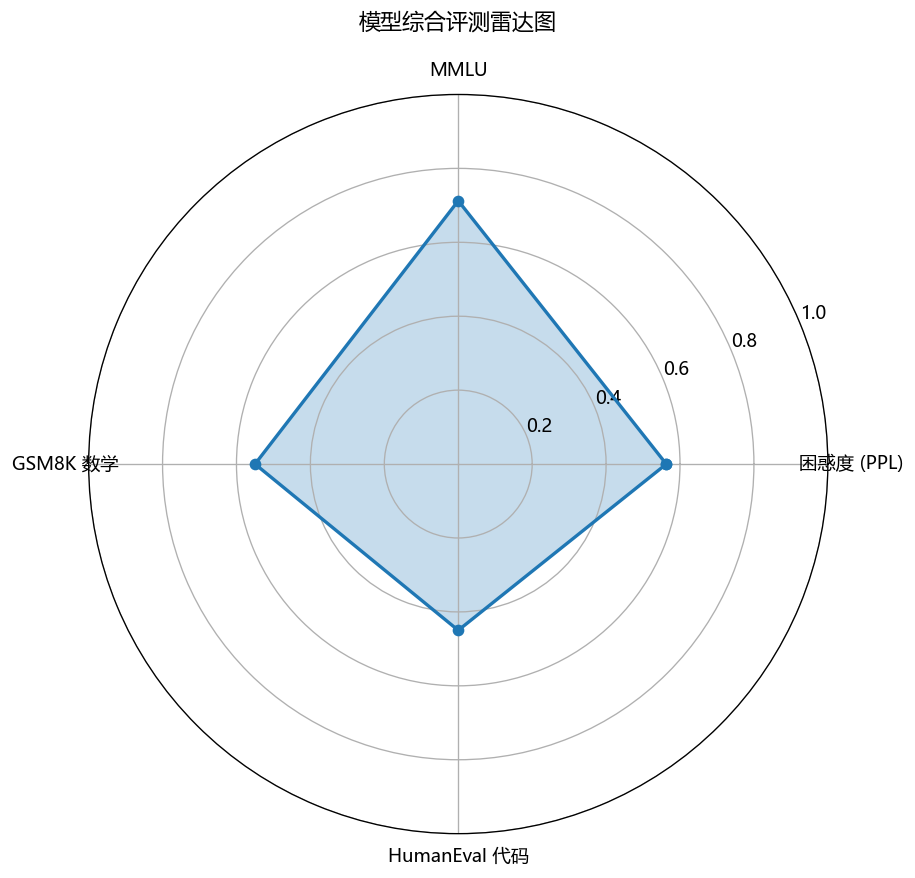

In [8]:
class ModelEvaluator:
    """
    综合模型评测器
    """
    def __init__(self):
        self.results = {}
    
    def evaluate_perplexity(self, model, test_data):
        """评估 PPL"""
        # 模拟
        np.random.seed(42)
        ppl = np.random.uniform(10, 100)
        self.results['困惑度 (PPL)'] = ppl
        return ppl
    
    def evaluate_mmlu(self, model, mmlu_data):
        """评估 MMLU"""
        np.random.seed(42)
        accuracy = np.random.uniform(0.6, 0.9)
        self.results['MMLU'] = accuracy
        return accuracy
    
    def evaluate_gsm8k(self, model, gsm8k_data):
        """评估 GSM8K"""
        np.random.seed(42)
        accuracy = np.random.uniform(0.4, 0.8)
        self.results['GSM8K 数学'] = accuracy
        return accuracy
    
    def evaluate_humaneval(self, model, humaneval_data):
        """评估代码生成"""
        np.random.seed(42)
        pass_rate = np.random.uniform(0.3, 0.7)
        self.results['HumanEval 代码'] = pass_rate
        return pass_rate
    
    def get_summary(self):
        """获取评测摘要"""
        return self.results
    
    def plot_radar(self):
        """雷达图可视化"""
        categories = list(self.results.keys())
        values = list(self.results.values())
        
        # 归一化
        normalized = []
        for i, (cat, val) in enumerate(zip(categories, values)):
            if '困惑度' in cat or 'PPL' in cat:
                normalized.append(1 - val/100)  # PPL 越低越好
            else:
                normalized.append(val)
        
        # 雷达图
        angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
        normalized += normalized[:1]
        angles += angles[:1]
        
        fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
        ax.plot(angles, normalized, 'o-', linewidth=2)
        ax.fill(angles, normalized, alpha=0.25)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories)
        ax.set_ylim(0, 1)
        plt.title('模型综合评测雷达图', pad=20)
        plt.show()

# 运行评测（固定随机种子保证可复现）
np.random.seed(42)
evaluator = ModelEvaluator()
evaluator.evaluate_perplexity(None, None)
evaluator.evaluate_mmlu(None, None)
evaluator.evaluate_gsm8k(None, None)
evaluator.evaluate_humaneval(None, None)

print("评测结果:")
for metric, value in evaluator.get_summary().items():
    if '困惑度' in metric or 'PPL' in metric:
        print(f"  {metric}: {value:.1f}")
    else:
        print(f"  {metric}: {value*100:.1f}%")

evaluator.plot_radar()

---

## 本章总结

### 核心概念图谱

```
                    ┌─────────────────┐
                    │      模型       │
                    │ (待评估 LLM)    │
                    └────────┬────────┘
                             │
            ┌────────────────┼────────────────┬────────────────┐
            ▼                ▼                ▼                ▼
   ┌────────────────┐ ┌───────────────┐ ┌──────────────┐ ┌──────────────┐
   │   PPL 困惑度    │ │  下游任务评测  │ │ LLM 评审     │ │  人类评估     │
   │                │ │              │ │ (LLM-as-    │ │              │
   │ exp(-1/N Σ     │ │ MMLU (知识)   │ │  Judge)     │ │ 标注者打分   │
   │  log P(w_i))  │ │ GSM8K (数学)  │ │              │ │ A/B 对比    │
   │                │ │ HumanEval    │ │ GPT-4 打分   │ │              │
   │ 自动 · 快速    │ │ (代码)       │ │ 成对比较     │ │ 金标准       │
   │ 局限性大       │ │              │ │              │ │ 成本高       │
   └────────┬───────┘ └──────┬───────┘ └──────┬───────┘ └──────┬───────┘
            └────────────────┴────────────────┴────────────────┘
                                      │
                                      ▼
                             ┌────────────────┐
                             │   综合评分      │
                             │ (雷达图/排行榜) │
                             └────────────────┘
```

### 关键公式速查

| 公式名称 | 表达式 | 说明 |
|:---------|:-------|:-----|
| 困惑度 (PPL) | $\text{PPL} = \exp\left(-\frac{1}{N}\sum_{i=1}^{N}\log P(w_i \mid w_{<i})\right)$ | 越低越好，但只衡量语言建模能力 |
| F1 分数 | $F_1 = \frac{2 \cdot P \cdot R}{P + R}$ | 精确率 P 和召回率 R 的调和平均 |
| Distinct-n | $\text{Distinct-n} = \frac{\text{unique n-grams}}{\text{total n-grams}}$ | 衡量生成多样性，越高越好 |
| Cohen's Kappa | $\kappa = \frac{p_o - p_e}{1 - p_e}$ | 标注者间一致性，>0.6 为较好 |

### 常见问题

> **Q1: PPL 很低就说明模型很好吗？PPL 的局限性是什么？**
> 不一定。PPL 只衡量语言建模能力（预测下一个词的准确性），不反映指令遵循、事实准确性、推理能力、安全性等关键维度。一个 PPL 很低的模型可能流畅地编造虚假事实或忽略用户指令。此外，不同 tokenizer 的 PPL 不可直接横向对比。

> **Q2: Benchmark 饱和（Saturation）是什么问题？如何应对？**
> 当多个强模型在某个 benchmark 上的分数都接近上限（如 MMLU 85-90%），该 benchmark 就无法有效区分模型能力了。应对方法：(1) 转向更难的 benchmark（GPQA、MATH-500、SWE-bench）；(2) 检测数据污染；(3) 使用动态评测（如 Chatbot Arena 实时人类投票）。

> **Q3: LLM-as-Judge 有哪些系统性偏差？**
> (1) 位置偏差——倾向选择出现在前面的回答，缓解方法是随机交换 A/B 位置；(2) 冗长偏差——倾向选择更长的回答，需在评分标准中强调简洁性；(3) 自我偏好——GPT-4 偏向自己的输出风格，应使用多个 Judge 交叉验证；(4) 格式偏差——使用 Markdown 的回答更易获高分。

> **Q4: 人工评估中，标注者间一致性（Inter-annotator Agreement）为什么重要？**
> 如果不同标注者对同一回答的评价差异很大（Cohen's Kappa < 0.4），说明评估标准不够清晰或任务过于主观，评估结果不可靠。主观任务（如"有帮助性"）的 Kappa 通常较低（0.3-0.5），客观任务（如"事实正确性"）较高（0.6-0.8）。低 Kappa 时应改进评估 rubric。

### 本章要点回顾

1. **Perplexity**
   - 衡量语言建模能力
   - 越低越好，但有局限性

2. **下游任务评测**
   - MMLU: 知识问答
   - GSM8K: 数学推理
   - HumanEval: 代码生成

3. **LLM-as-a-Judge**
   - 用强模型评估弱模型
   - 可以评估主观质量

### 评测最佳实践

1. **多维度评估**：不要只看一个指标
2. **统一协议**：固定 prompt/温度/采样参数
3. **定期评测**：监控模型变化
4. **公平对比**：同数据同预算，避免污染
5. **人工抽检**：自动化不能替代人工

**备注：** 本章所有数值/图表为模拟示例。

---

## 🔗 下一步

**你已掌握：** 模型评估的完整方法论——Perplexity 困惑度、MMLU/GSM8K 下游任务评测、LLM-as-Judge 评审方法，以及多维度综合评测框架。

**完成了全部课程内容！** 你现在拥有从预训练到评估的完整 LLM 知识体系：
- **基础架构**：Transformer、GPT、Tokenizer
- **训练技术**：预训练、SFT、LoRA/QLoRA
- **对齐方法**：DPO、RLHF
- **工程优化**：KV Cache
- **应用系统**：Agent、RAG
- **评估体系**：PPL、Benchmark、LLM-as-Judge

### 📖 延伸阅读
- [Chatbot Arena: An Open Platform for Evaluating LLMs (Zheng et al., 2023)](https://arxiv.org/abs/2403.04132) — 基于人类投票的 LLM 排行榜
- [Holistic Evaluation of Language Models (HELM) (Liang et al., 2022)](https://arxiv.org/abs/2211.09110) — Stanford 的全面 LLM 评估框架
- [Judging LLM-as-a-Judge (Zheng et al., 2023)](https://arxiv.org/abs/2306.05685) — MT-Bench 与 LLM 评审方法论

In [9]:
# 练习空间

